# Describing a Gel's Behavior at High Strain

One way to characterize materials is its behavior under stress. Typically, there is an initial linear elastic phase at low strain. In this phase, the material can still return to its original shape. Beyond that is the plastic phase where the material either undergoes permanent deformation or fractures.

In this project, we were interested in seeing if the linear-nonlinear transition point was consistent for our gel of interest and if it varied greatly between conditions.

## Extracting Displacements & Calculating Stress and Strain

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import binned_statistic

from analysis_tools.image_analysis import load_images_high_strain
from analysis_tools.stress_strain import get_positions, get_displacements_strains_forces, sort_unique_strain_stress

plt.rcParams.update({
    "font.family" : "serif",
    "font.serif" : ["Times New Roman", "DejaVu Serif", "serif"],
    "font.size" : 15,
    "figure.dpi" : 300,
    "savefig.bbox" : "tight"
})

Create an Excel file with a first sheet named "metadata". 

It should be organized as follows :
| Condition | Gel | Analyze | Type | w_min | w_1 | w_2 | l_rod | Rigid Stop |
| :--: | :--: | :--: | :--: | :--: | :--: | :--: | :--: | :--: |
| _str_ | _int_ | 0 to skip / 1 to analyze | detach / tear / fracture / stretch | _float_ | _float_ | _float_ | _float_ | frame to stop at / last frame |

This file will be used for the rest of the following steps.

In [3]:
root = ".."
dates = ["26-04-13"]
step_bool = True

In [ ]:
for d in dates :
    print(f"{d}")
    excel_path = Path(root) / d / f"{d}_fracture.xlsx"
    xl_file = pd.ExcelFile(excel_path)
    metadata = pd.read_excel(xl_file, sheet_name="metadata")

    for i in range(metadata.shape[0]) :
        sample = metadata.iloc[i]
        if sample["Analyze"] : 
            c = sample["Condition"]; g = sample["Gel"]

            w = np.mean([sample["w_min"], sample["w_1"], sample["w_2"]])
            l = sample["l_rod"]

            print(f"\t{d} {c} {g} -- {sample["Type"]}")
            gel_path = Path(root) / d / c / f"gel{g}" / "RampToFracture_1" / "Default"

            rigid_stop = sample["Rigid Stop"]
            if step_bool :
                nb_frames = len(os.listdir(gel_path)) - 1

                steps = 100
                if nb_frames/steps < 10 : steps = 10
                frames_idx = np.arange(0, nb_frames, steps)

                idx_diff = [abs(rigid_stop - idx) for idx in frames_idx]
                for i in range(nb_frames) :
                    if idx_diff[i] == min(idx_diff) : 
                        rigid_stop = i
                        break
                print()

            try :
                img_lst = load_images_high_strain(gel_path, step=step_bool)
                f_pos, _, r_pos = get_positions(img_lst)
                res, graph = get_displacements_strains_forces(f_pos, r_pos, rigid_stop, w, l, sample["Type"])

                res_pd = pd.DataFrame.from_dict(res)

                file_path = Path(root) / d / f"{d}_fracture.xlsx"
                with pd.ExcelWriter(file_path, engine="openpyxl", mode="a", if_sheet_exists='replace') as writer :
                    res_pd.to_excel(writer, sheet_name=f"{c} gel{g}", index=False, startrow=0)

            except Exception as error : 
                print(f"\n\tfailed {d} {c} {g} ({sample["Type"]}) because of {error}")

## Data Processing

A sheet for each gel is created and is organized as follows :

| flexible position | rigid position | flexible displacement | rigid displacement | fitted rigid | lengths | strains | stress | lower bound | upper bound |
| :--: | :--: | :--: | :--: | :--: | :--: | :--: | :--: | :--: | :--: | 

Only the lower bound and upper bound columns will have a single value, which would be the row indexes of the data that should be considered in further calculations and plotting. 

### Select Gel to Process

In [ ]:
print(dates)

In [ ]:
## choose the Excel file
excel_path = Path(root) / d / f"{d}_fracture.xlsx"
xl_file = pd.ExcelFile(excel_path)
metadata = pd.read_excel(xl_file, sheet_name="metadata")

## all gel sheets (skip metadata)
sheets = xl_file.sheet_names[1:]

## display metadata to see gel conditions, whether or not they were analyzed, and their end behavior type
display(metadata)

In [ ]:
## select the gel/sheet to process
sheet = sheets[idx] ## change idx as needed
print(sheet)

gel = pd.read_excel(xl_file, sheet_name=sheet)
display(gel.head())
print(gel.shape)

### Checking and Fitting the Strain

The strains depend on the lengths, with depend on the flexible and rigid displacements. While the flexible displacement has empirically seemed to be clean, that is not the case for the rigid displacment. Thus, a linear fit was used.

Ensuring that this linear fit is coherent is the first step.

Because the fit has to be calculated from the original positions and displacments, these should not be changed so that the original calculations can be restored, if needed.

In [ ]:
## (!) These values should not be changed in the dataframe.
f_pos = gel["flexible position"]
r_pos = gel["rigid position"]
f_d = gel["flexible displacement"]
r_d = gel["rigid displacement"]

In [ ]:
r_fit = gel["fitted rigid displacement"]

In [ ]:
## visualize flexible, rigid, and fitted rigid displacement v. frame number
plt.plot(np.arange(len(f_d)), f_d, color="blue")
plt.plot(np.arange(len(r_d)), r_d, color="pink")
plt.plot(np.arange(len(r_fit)), r_fit, color="red", linestyle="--")
plt.show()

In [ ]:
## test indexes 
test_lower_limit = 0; test_upper_limit = 375; test_y_int = 0

x_plot = np.arange(len(r_d))

## get rigid displacement values within range of the test indexes
r_x_fit = []; r_y_fit = []
for i in range(test_lower_limit, test_upper_limit) :
    if r_d[i] > 0 : ## only keep positive values
        r_x_fit.append(x_plot[i])
        r_y_fit.append(r_d[i] + test_y_int)

## find the linear fit of the new range of rigid displacement values
r_slope, y_int = np.polyfit(r_x_fit, r_y_fit, deg=1)
r_test_fit = np.multiply(x_plot, r_slope) + y_int

## visualize new fitted rigid displacement and compare
plt.plot(np.arange(len(f_d)), f_d, color="blue")
plt.plot(np.arange(len(r_d)), r_d, color="pink")
plt.plot(np.arange(len(r_test_fit)), r_test_fit, color="red", linestyle="--", alpha=0.5)
plt.axvline(test_lower_limit); plt.axvline(test_upper_limit)
plt.show()

In [ ]:
## get new fitted rigid displacements values
r_fit_pos = [r_pos[0] + (n * 265) for n in r_test_fit]

## recalculate lengths
lengths = [((r_fit_pos[i] - f_pos[i])/265) - 1 for i in range(len(r_fit_pos))]

## recalculate strain
strain = [(l-lengths[0])/lengths[0] for l in lengths]

## update fitted rigid displacement, lengths, and strains, in gel's dataframe
gel["fitted rigid displacement"] = r_test_fit
gel["lengths"] = lengths
gel["strains"] = strain

### Checking and Setting the Bounds

In [ ]:
## visualize the stress v. strain plot
fig, axs = plt.subplots(1,2, figsize=(10,5))

lower_bound = int(gel["lower bound"][0]); upper_bound = int(gel["upper bound"][0])
strain = gel["strains"]; stress = gel["stress"]

axs[0].plot(strain, stress, color="blue")
axs[0].plot(strain[lower_bound:upper_bound], stress[lower_bound:upper_bound], color="red")

axs[1].plot(strain[lower_bound:upper_bound], stress[lower_bound:upper_bound])
plt.show()

In [ ]:
## visualize where the new upper bound should be
upper_bound = ub ## change ub as needed

plt.plot(strain[upper_bound-20:upper_bound+20], stress[upper_bound-20:upper_bound+20], marker=".")
plt.axvline(strain[upper_bound])
plt.show()

In [ ]:
gel["upper bound"] = [ub] + [np.nan] * (gel.shape[0] - 1)

### Update Excel file

In [ ]:
## check that the changes have been correctly made in the data frame
display(gel.head())

In [ ]:
## (!) I recommend to keep this as a triple-quotation-mark comment to avoid unwanted changes when hastily executing cells.
with pd.ExcelWriter(excel_path, engine="openpyxl", mode="a", if_sheet_exists='replace') as writer :
    gel.to_excel(writer, sheet_name=sheet, index=False, startrow=0)

## Data Visualization

In [4]:
# automatically get all conditions 
conditions = []

for d in dates :
    excel_path = Path(root) / "data" / f"{d}_high_strain.xlsx"
    xl_file = pd.ExcelFile(excel_path)
    metadata = pd.read_excel(xl_file, sheet_name="metadata")

    for i in range(metadata.shape[0]) :
        sample = metadata.iloc[i]
        c = sample["Condition"]
        if sample["Analyze"] and c not in conditions : conditions.append(c)

conditions = sorted(conditions) ## or explicitly select conditions of interest

In [5]:
## get color maps (using 2 maximizes the number of colors available in the case of many conditions)
plasma_cmap = mpl.colormaps["plasma"]; viridis_cmap = mpl.colormaps["viridis"]

## divide each color map so that there are exactly the same number of colors as there are conditions
s1 = len(conditions)//2; s2 = len(conditions) - s1

plasma_colors = list(plasma_cmap(np.linspace(start=0, stop=0.9, num=s1)))
viridis_colors = list(reversed(list(viridis_cmap(np.linspace(start=0.3, stop=0.9, num=s2)))))
pv_colors = plasma_colors + viridis_colors ## add colormaps together

## assign colors
colors = {conditions[i]:pv_colors[i] for i in range(len(conditions))}

In [6]:
## assign subplot indexes 
sp_idx = {conditions[i]:i for i in range(len(conditions))}

### Individual Samples

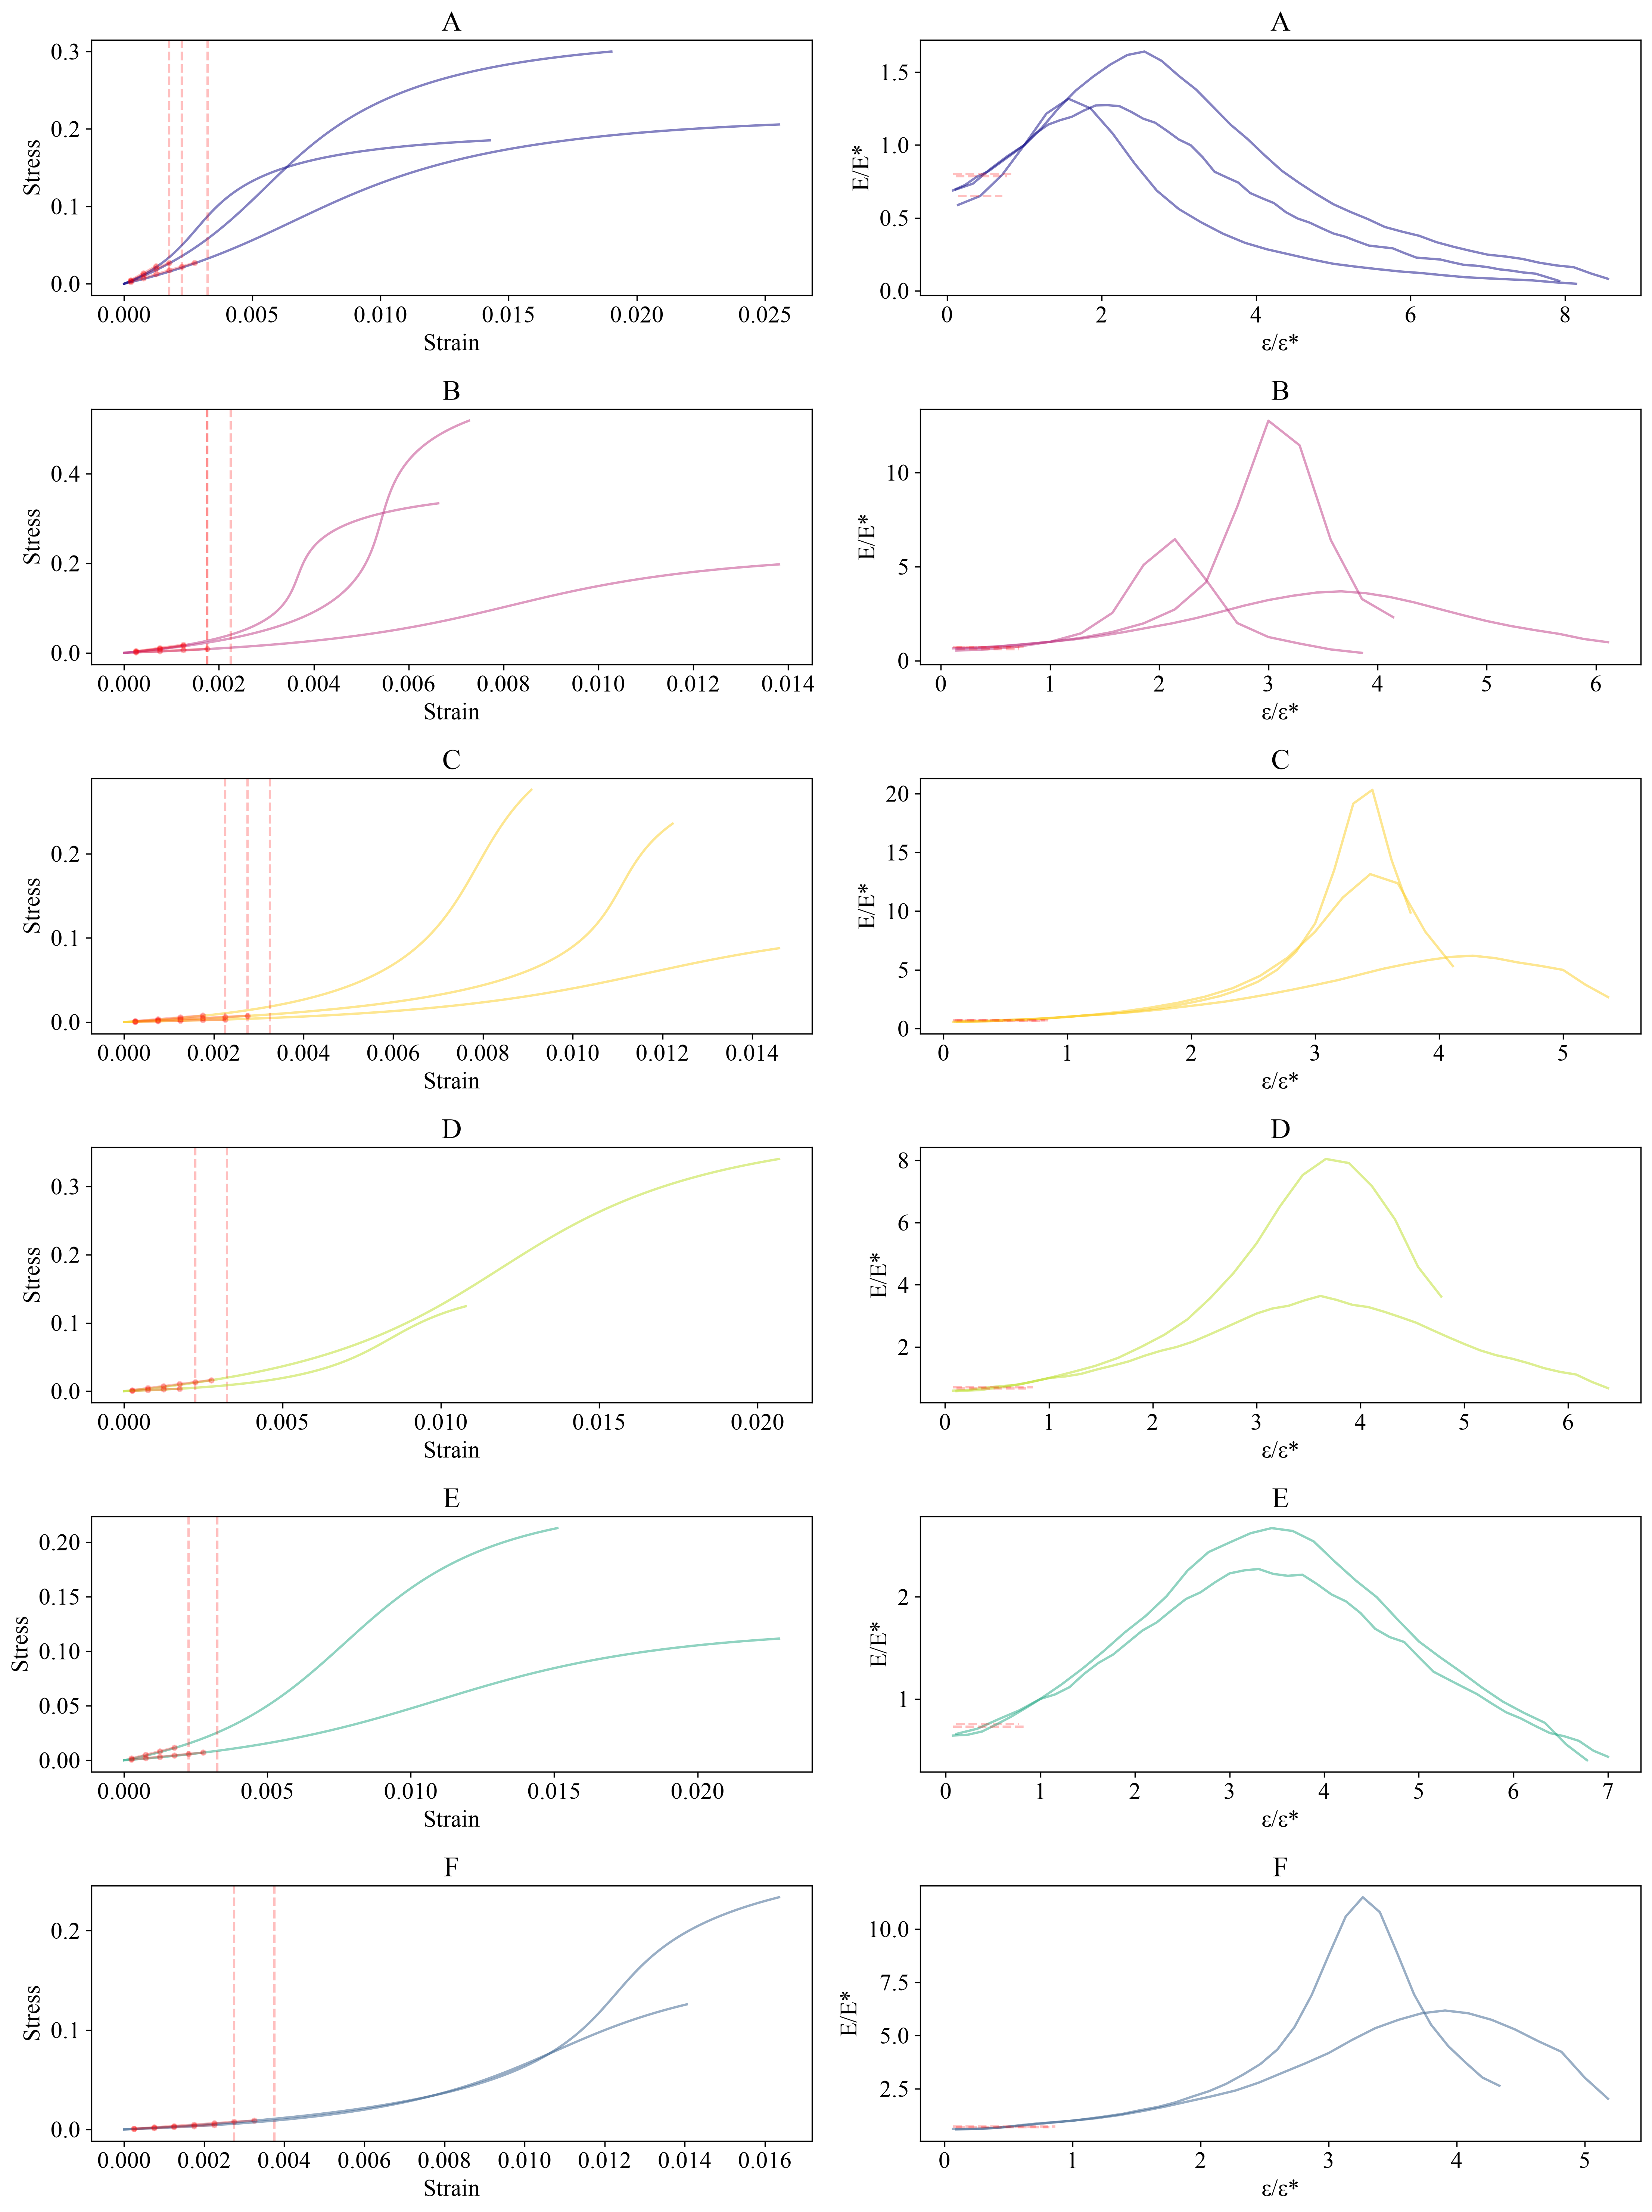

In [7]:
## preparation for generalized curves
stress_strain_curves = {c:[] for c in conditions} 
E_epsilon_curves = {c:[] for c in conditions}

fig, axs = plt.subplots(len(conditions), 2, figsize=(15,20))

for d in dates :
    excel_path = Path(root) / "data" / f"{d}_high_strain.xlsx" ## change as needed
    
    xl_file = pd.ExcelFile(excel_path)
    metadata = pd.read_excel(xl_file, sheet_name="metadata")

    for i in range(metadata.shape[0]) :
        sample = metadata.iloc[i]
        if sample["Analyze"] :
            condition = sample["Condition"]
            gel_id = sample["Gel"]

            gel = pd.read_excel(xl_file, sheet_name=f"{condition} gel{gel_id}")

            raw_strain = gel["strains"]; raw_stress = gel["stress"]
            upper_bound = int(gel["upper bound"][0])

            strain, stress = sort_unique_strain_stress(raw_strain[:upper_bound], raw_stress[:upper_bound])

            ## smoothing

            bin_step = 0.0005 ## 0.02
            binned = np.arange(0, max(strain) + bin_step, bin_step)
            stress_b_aux, bin_edges, _ = binned_statistic(
                strain,
                stress,
                statistic="mean",
                bins = binned
            )
            strain_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

            nonnan_mask = ~np.isnan(stress_b_aux)
            inc_mask = np.diff(stress_b_aux, prepend=stress_b_aux[0] - 1) > 0
            bin_mask = nonnan_mask & inc_mask

            strain_binned = strain_centers[bin_mask]
            stress_binned = stress_b_aux[bin_mask]

            stress_strain_curves[condition].append((strain_binned, stress_binned))

            ## finding the linear elastic phase
            linear_candidates = dict(); r2_lst = []

            ## expanding window from low to high strain
            for i in range(2, len(strain_binned)) :
                
                ## fit a linear line to the range of values
                slope, y_int = np.polyfit(strain_binned[:i], stress_binned[:i], deg=1)
                linear_fit = np.multiply(strain_binned[:i], slope) + y_int

                ## see how well the linear line fits with the actual stress values
                residuals = stress_binned[:i] - linear_fit
                ss_res = np.sum(residuals ** 2)
                y_mean = np.mean(stress_binned[:i])
                ss_tot = np.sum((stress_binned - y_mean) ** 2)

                r2 = 1 - (ss_res / ss_tot); r2_lst.append(r2)

                ## if it fits really well, then consider the point to be in the linear phase
                if r2 > 0.999999 : linear_candidates[i] = (strain_binned[i], stress_binned[i], slope)

            ## the highest strain in the linear candidates should be the limit of the linear phase
            crit_idx = max(linear_candidates); trans_point = linear_candidates[crit_idx]

            strain_crit = trans_point[0]; stress_crit = trans_point[1]; linear_slope = trans_point[2]

            ## get fitted linear phase
            linear_x = strain_binned[:crit_idx]; linear_y_fit = np.multiply(linear_x, linear_slope)

            ## find the derivative of stress -> E
            E = np.gradient(stress_binned, strain_binned)
            E_crit = E[crit_idx]

            ## normalize E and strain by transition point
            E_normalized = E / E_crit
            strain_normalized = strain_binned / strain_crit

            E_epsilon_curves[condition].append((strain_normalized, E_normalized))

            ## plot stress v. strain

            ## original stress and strain values
            axs[sp_idx[condition], 0].plot(strain, stress, color=colors[condition], alpha=0.5)

            ## fitted linear phase 
            axs[sp_idx[condition], 0].plot(linear_x, linear_y_fit, color="red", marker=".", alpha=0.25)

            ## linear-nonlinear transition point
            axs[sp_idx[condition], 0].axvline(strain_crit, color="red", linestyle="--", alpha=0.25)

            ## plot normalized E v. strain
            
            ## calculated normalized E and strain values
            axs[sp_idx[condition], 1].plot(strain_normalized, E_normalized, color=colors[condition], alpha=0.5)

            ## calculated E (linear slope) for the linear phase
            axs[sp_idx[condition], 1].plot(strain_normalized[:crit_idx], ([linear_slope] * crit_idx)/E_crit, color="red", linestyle="--", alpha=0.25)

            axs[sp_idx[condition], 0].set_xlabel("Strain")
            axs[sp_idx[condition], 0].set_ylabel("Stress")

            axs[sp_idx[condition], 1].set_xlabel("ε/ε*")
            axs[sp_idx[condition], 1].set_ylabel("E/E*")

            axs[sp_idx[condition], 0].title.set_text(condition)
            axs[sp_idx[condition], 1].title.set_text(condition)

plt.tight_layout()
plt.show()

### Generalized Curves to Compare Conditions

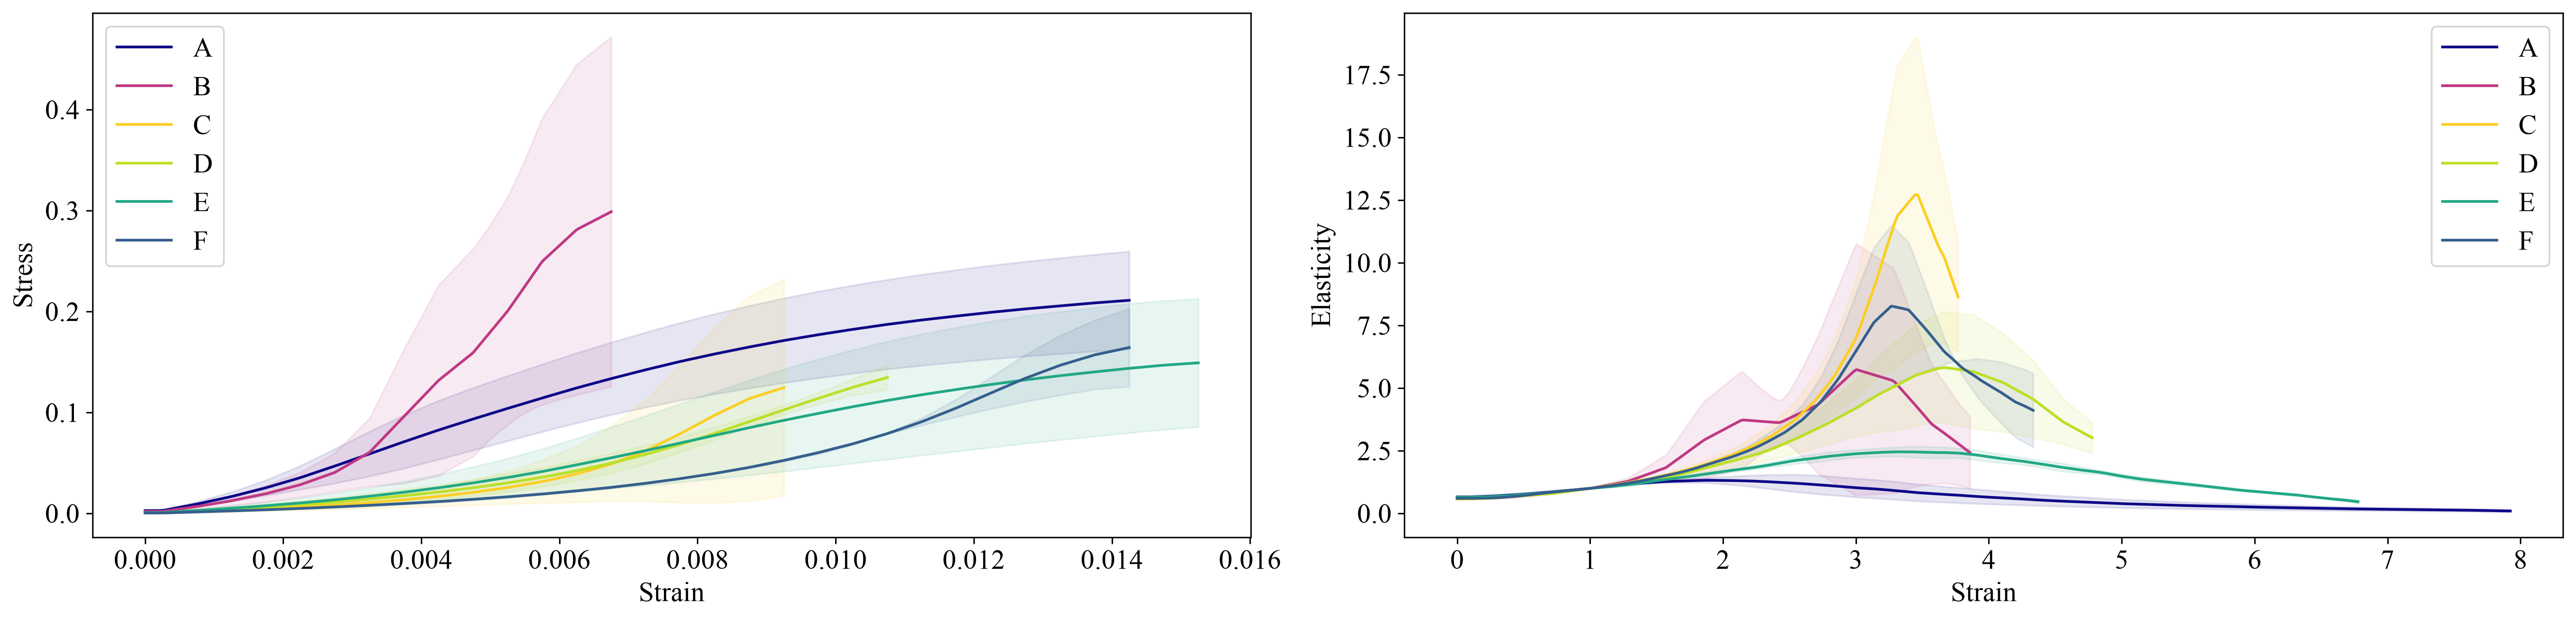

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(20,5))
for i, d in {0:stress_strain_curves, 1:E_epsilon_curves}.items() :
    for c, lst in d.items() :
        max_common_strain = min([np.max(strain) for strain, _ in lst])
        master_strain = np.linspace(0, max_common_strain, 200)

        interpolated_stress = []
        for strain_i, stress_i in lst :
            stress_interpolated = np.interp(master_strain, strain_i, stress_i)
            interpolated_stress.append(stress_interpolated)

        stress_mean = np.mean(interpolated_stress, axis=0)
        stress_std = np.std(interpolated_stress, axis=0)

        axs[i].plot(master_strain, stress_mean, color=colors[c])
        axs[i].fill_between(
            master_strain,
            stress_mean - stress_std,
            stress_mean + stress_std,
            color=colors[c],
            alpha=0.1
        )

for i in range(2) :
    for c1, c2 in colors.items() :
        axs[i].plot(0,0, color=c2, label=c1)

axs[0].set_xlabel("Strain"); axs[0].set_ylabel("Stress"); axs[0].legend()
axs[1].set_xlabel("Strain"); axs[1].set_ylabel("Elasticity"); axs[1].legend()
plt.tight_layout()
plt.show()